<a href="https://colab.research.google.com/github/AlvarFeher/TFG/blob/main/Gnn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from google.colab import drive
drive.mount('/content/drive')
filename = "/content/drive/MyDrive/TFG/data/graph.pkl"
filenameDF = "/content/drive/MyDrive/TFG/data/clustered_nodes_df.pkl"
filenamePhotons = "/content/drive/MyDrive/TFG/data/clusters_photon_energy_top10_events_optimized (1).csv"
filenameNodes = "/content/drive/MyDrive/TFG/data/nodes_with_cluster_ids_top10_events_optimized.csv"
!pip install awkward pandas awkward-pandas
!pip install torch-geometric

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import pandas as pd
import torch
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from sklearn.preprocessing import StandardScaler

# Load your nodes dataset
df = pd.read_csv(filenameNodes)

# Map the "type" column (if "type" indicates if a node is a seed or neighbor)
df["type"] = df["type"].map({"seed": 1, "neighbor": 0})

# Define feature and target columns
node_features = ["row", "column", "MCID", "type"]
target_column = "energy"

# Scale features and target values
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Note: These scaled values are not used directly in the graph conversion below,
# but you could later use them to normalize training if desired.
X_scaled = scaler_x.fit_transform(df[node_features])
y_scaled = scaler_y.fit_transform(df[[target_column]])

# Create a NetworkX graph
G = nx.Graph()

# Add nodes to G with tensor attributes for features and target.
# Ensure each attribute is a tensor with shape (1, num_features) for consistency.
for idx, row in df.iterrows():
    node_id = int(row["node_id"])  # Ensure node ID is an integer
    # Convert the features to a tensor and reshape to (1, -1)
    features = torch.tensor(row[node_features].values.astype(float), dtype=torch.float).view(1, -1)
    # Convert the target value to a tensor with shape (1,)
    target = torch.tensor([float(row[target_column])], dtype=torch.float).view(1, -1)
    G.add_node(node_id, features=features, target=target)

# Add edges connecting all nodes within the same cluster
for cluster_id in df["clusterId"].unique():
    cluster_nodes = df[df["clusterId"] == cluster_id]["node_id"].values
    # Fully connect nodes in this cluster
    for i in range(len(cluster_nodes)):
        for j in range(i + 1, len(cluster_nodes)):
            G.add_edge(int(cluster_nodes[i]), int(cluster_nodes[j]))

print(f"Number of Nodes: {G.number_of_nodes()}")
print(f"Number of Edges: {G.number_of_edges()}")
first_node = list(G.nodes())[0]
print(f"First Node ID: {first_node}")
print(f"Node Attributes: {G.nodes[first_node]}")

# Convert the NetworkX graph to a PyTorch Geometric Data object.
# Do not pass group_edge_attrs (or pass None) to avoid issues with empty lists.
graph_data = from_networkx(G, group_node_attrs=["features", "target"])

print("Successfully converted to PyG Data object.")
if hasattr(graph_data, "target"):
    # Ensure it's a 2D tensor
    if graph_data.target.dim() == 1:
        graph_data.y = graph_data.target.view(-1, 1)
    else:
        graph_data.y = graph_data.target
# (Optional) If you want a graph-level target (e.g., total cluster energy),
# you can compute it and assign it as graph_data.y. For example:
cluster_energy = df.groupby("clusterId")[target_column].sum().values
graph_data.y = torch.tensor(cluster_energy, dtype=torch.float)

# Verify the PyG Data object structure
print(graph_data)
print(f"Node Features Shape: {graph_data.x.shape if hasattr(graph_data, 'x') else 'Not available'}")
# Sometimes, when using group_node_attrs, attributes may be stored as separate fields.
print(f"Graph 'target' attribute shape: {graph_data.target.shape if hasattr(graph_data, 'target') else 'Not available'}")



Number of Nodes: 11850
Number of Edges: 2179605
First Node ID: 5120
Node Attributes: {'features': tensor([[37.,  4., 22.,  0.]]), 'target': tensor([[-26.4240]])}
Successfully converted to PyG Data object.
Data(edge_index=[2, 4359210], x=[11850, 1, 5], y=[961])
Node Features Shape: torch.Size([11850, 1, 5])
Graph 'target' attribute shape: Not available


In [32]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
# Definir el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class GNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, model_type="GAT"):
        super(GNNModel, self).__init__()

        if model_type == "GAT":
            self.conv1 = GATConv(input_dim, hidden_dim, heads=4, dropout=0.2)
            self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, dropout=0.2)
        elif model_type == "GCN":
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == "GraphSAGE":
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)
        else:
            raise ValueError("Invalid model type. Choose 'GAT', 'GCN', or 'GraphSAGE'.")

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x


In [33]:
import torch.optim as optim

# Define Model & Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = graph_data.x.shape[1]
hidden_dim = 64
print("Before:", graph_data.y.shape)  # e.g. torch.Size([N])
if graph_data.y.dim() == 1:
    graph_data.y = graph_data.y.unsqueeze(-1)

print("After:", graph_data.y.shape)   # e.g. torch.Size([N, 1])

output_dim = graph_data.y.shape[1]

model = GNNModel(input_dim, hidden_dim, output_dim, model_type="GAT").to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.MSELoss()

# Move data to device
graph_data = graph_data.to(device)

# Training Loop
epochs = 300
train_losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(graph_data)
    loss = criterion(out, graph_data.y)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")


Before: torch.Size([961])
After: torch.Size([961, 1])


AssertionError: Static graphs not supported in 'GATConv'

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_gnn = model(graph_data).cpu().numpy()

# Inverse Transform Predictions
y_pred_gnn_orig = scaler_y.inverse_transform(y_pred_gnn)
y_test_orig = scaler_y.inverse_transform(graph_data.y.cpu().numpy())


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to visualize GNN predictions vs true values
def visualize_gnn_predictions(y_test_orig, y_pred_gnn_orig):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_orig, y_pred_gnn_orig, alpha=0.6, label="Predictions", color="purple")
    plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', label="Ideal")
    plt.xlabel("True Energy")
    plt.ylabel("Predicted Energy")
    plt.title("GNN: Predictions vs True")
    plt.legend()
    plt.show()

#Function to visualize Residuals (Error Distribution)
def visualize_gnn_residuals(y_test_orig, y_pred_gnn_orig):
    plt.figure(figsize=(6, 6))
    residuals = y_test_orig - y_pred_gnn_orig
    plt.hist(residuals.flatten(), bins=50, alpha=0.7, color="purple")
    plt.xlabel("Residual (True - Predicted)")
    plt.ylabel("Frequency")
    plt.title("GNN Residuals")
    plt.show()

# Run the visualization functions
visualize_gnn_predictions(y_test_orig, y_pred_gnn_orig)
visualize_gnn_residuals(y_test_orig, y_pred_gnn_orig)


# **APPROACH 2**

In [55]:
import pandas as pd
import torch
import networkx as nx
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.utils import from_networkx
from sklearn.preprocessing import StandardScaler

# --- Load your nodes dataset ---
df = pd.read_csv(filenameNodes)

# Convert the "type" column to numeric.
# (Assuming "seed" means 1 and "neighbor" means 0.)
df["type"] = df["type"].map({"seed": 1, "neighbor": 0})

# Define which columns are features and which column is the per-node energy.
node_features = ["row", "column", "MCID", "type"]
target_column = "energy"

# We will use the raw values for features and target,
# but you can also choose to scale them later (for the entire dataset).
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# Fit scalers on all nodes (if desired). Here, we scale features only.
df[node_features] = scaler_x.fit_transform(df[node_features])
# For target scaling, we will use it later on the aggregated targets.

# Compute the graph-level target per cluster (e.g. sum of energies per cluster)
cluster_targets = df.groupby("clusterId")[target_column].sum().reset_index()
cluster_targets.rename(columns={target_column: "cluster_energy"}, inplace=True)

# Optionally, scale the cluster targets (we fit the scaler on the target values)
cluster_targets["cluster_energy_scaled"] = scaler_y.fit_transform(cluster_targets[["cluster_energy"]])
# Compute the graph-level target per cluster (e.g. sum of energies per cluster)
cluster_targets = df.groupby("clusterId")[target_column].sum().reset_index()
cluster_targets.rename(columns={target_column: "cluster_energy"}, inplace=True)

# Optionally, scale the cluster targets
cluster_targets["cluster_energy_scaled"] = scaler_y.fit_transform(cluster_targets[["cluster_energy"]])

# ---- Insert the train-test split here ----
from sklearn.model_selection import train_test_split

# Get unique cluster IDs
unique_clusters = df["clusterId"].unique()

# Split cluster IDs into training (80%) and testing (20%)
train_clusters, test_clusters = train_test_split(unique_clusters, test_size=0.2, random_state=42)

# Filter the DataFrame to get training and testing subsets
df_train = df[df["clusterId"].isin(train_clusters)].copy()
df_test = df[df["clusterId"].isin(test_clusters)].copy()

# Similarly, filter the cluster targets DataFrame
cluster_targets_train = cluster_targets[cluster_targets["clusterId"].isin(train_clusters)].copy()
cluster_targets_test = cluster_targets[cluster_targets["clusterId"].isin(test_clusters)].copy()
# -------------------------------------------

# Create the PyG datasets for training and testing
train_dataset = ClusterGraphDataset(df_train, cluster_targets_train)
test_dataset = ClusterGraphDataset(df_test, cluster_targets_test)

print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of testing graphs: {len(test_dataset)}")


# --- Create a PyG Dataset where each graph is one cluster ---
class ClusterGraphDataset(InMemoryDataset):
    def __init__(self, df, cluster_targets, transform=None, pre_transform=None):
        super(ClusterGraphDataset, self).__init__('.', transform, pre_transform)
        self.df = df
        self.cluster_targets = cluster_targets
        self.data_list = self.build_graphs()
        self.data, self.slices = self.collate(self.data_list)

    def build_graphs(self):
        data_list = []
        # For each unique cluster, build a graph
        for cluster_id in self.df["clusterId"].unique():
            cluster_df = self.df[self.df["clusterId"] == cluster_id]

            # Create a NetworkX graph for this cluster.
            # We'll add each node with its features.
            G = nx.Graph()
            for idx, row in cluster_df.iterrows():
                node_id = int(row["node_id"])
                # Get features as a tensor (make it 1D; no extra dimension)
                features = torch.tensor(row[node_features].values.astype(float), dtype=torch.float).view(1, -1)
                G.add_node(node_id, features=features)

            # Fully connect nodes in this cluster
            cluster_nodes = cluster_df["node_id"].values
            for i in range(len(cluster_nodes)):
                for j in range(i + 1, len(cluster_nodes)):
                    G.add_edge(int(cluster_nodes[i]), int(cluster_nodes[j]))

            # Convert the NetworkX graph to a PyG Data object.
            # We only group the "features" attribute.
            data = from_networkx(G, group_node_attrs=["features"])
            # After conversion, data.x has shape [num_nodes, 1, num_features].
            # We can squeeze out the extra dimension:
            data.x = data.x.squeeze(1)  # Now shape [num_nodes, num_features]

            # Get the graph-level target for this cluster.
            # Look up the aggregated energy from cluster_targets.
            target_val = cluster_targets.loc[cluster_targets["clusterId"] == cluster_id, "cluster_energy_scaled"].values
            if len(target_val) == 0:
                continue  # Skip if no target found
            # We want the graph label to be a tensor of shape [1]
            data.y = torch.tensor(target_val, dtype=torch.float)
            # Optionally, store the cluster_id (for later analysis)
            data.cluster_id = cluster_id

            data_list.append(data)
        return data_list

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

# Create the dataset
dataset = ClusterGraphDataset(df, cluster_targets)

print(f"Number of graphs (clusters): {len(dataset)}")
# Inspect one graph:
print(dataset[0])


Number of training graphs: 768
Number of testing graphs: 193
Number of graphs (clusters): 961
Data(edge_index=[2, 152490], x=[391, 4], y=[1], cluster_id=90)


In [56]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool

class ClusterEnergyGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, model_type="GCN"):
        super(ClusterEnergyGNN, self).__init__()
        if model_type == "GAT":
            self.conv1 = GATConv(input_dim, hidden_dim, heads=4, dropout=0.2)
            self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, dropout=0.2)
        elif model_type == "GCN":
            from torch_geometric.nn import GCNConv
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
        elif model_type == "GraphSAGE":
            from torch_geometric.nn import SAGEConv
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        else:
            raise ValueError("Invalid model type. Choose 'GAT', 'GCN', or 'GraphSAGE'.")

        # Final fully-connected layer to output the graph prediction (cluster energy)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        # Global pooling: aggregate node features to graph representation
        x = global_mean_pool(x, batch)
        # Final prediction
        x = self.fc(x)
        return x.squeeze()  # Return 1D tensor (one prediction per graph)

# Determine input dimension from the dataset
input_dim = dataset[0].x.shape[1]
hidden_dim = 64
output_dim = 1  # Predict a single scalar (scaled cluster energy)

model = ClusterEnergyGNN(input_dim, hidden_dim, output_dim, model_type="GAT")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [58]:
from torch_geometric.loader import DataLoader

loader = DataLoader(dataset, batch_size=32, shuffle=True)


In [59]:
from torch_geometric.loader import DataLoader

# Create DataLoaders for training and testing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [65]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

num_epochs = 50
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.num_graphs
    epoch_loss /= len(dataset)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 0/50, Loss: 0.5538
Epoch 20/50, Loss: 0.0538
Epoch 40/50, Loss: 0.0060


In [66]:
import numpy as np
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch).cpu().numpy()
        targets = batch.y.cpu().numpy()
        # Ensure that each array has at least one dimension
        all_preds.append(np.atleast_1d(preds))
        all_targets.append(np.atleast_1d(targets))

# Concatenate predictions and targets from all batches
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Inverse transform predictions and targets (assuming scaler_y was fitted on the cluster energies)
all_preds_orig = scaler_y.inverse_transform(all_preds.reshape(-1, 1)).flatten()
all_targets_orig = scaler_y.inverse_transform(all_targets.reshape(-1, 1)).flatten()


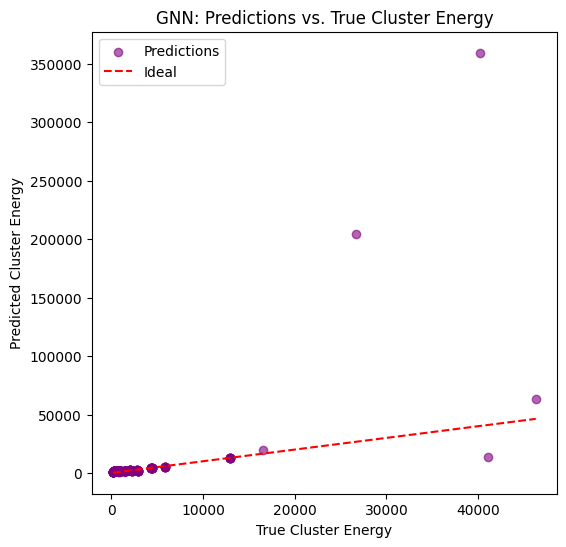

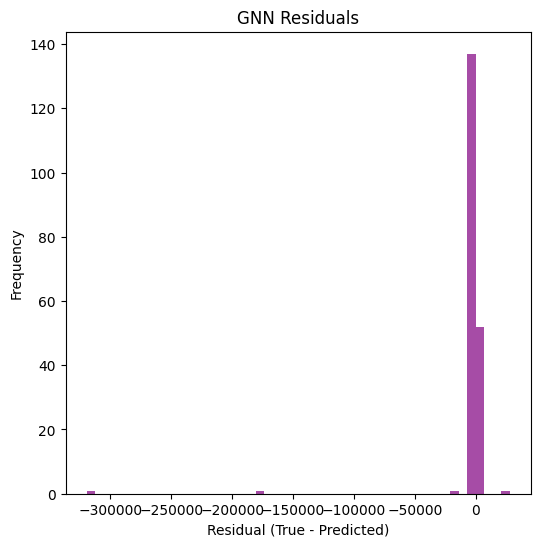

In [67]:
import matplotlib.pyplot as plt

# Scatter plot: True vs. Predicted Cluster Energy
plt.figure(figsize=(6, 6))
plt.scatter(all_targets_orig, all_preds_orig, alpha=0.6, label="Predictions", color="purple")
plt.plot([all_targets_orig.min(), all_targets_orig.max()],
         [all_targets_orig.min(), all_targets_orig.max()],
         'r--', label="Ideal")
plt.xlabel("True Cluster Energy")
plt.ylabel("Predicted Cluster Energy")
plt.title("GNN: Predictions vs. True Cluster Energy")
plt.legend()
plt.show()

# Residuals histogram: Distribution of errors
residuals = all_targets_orig - all_preds_orig
plt.figure(figsize=(6, 6))
plt.hist(residuals, bins=50, alpha=0.7, color="purple")
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Frequency")
plt.title("GNN Residuals")
plt.show()


In [68]:
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        preds = model(batch).cpu().numpy()
        targets = batch.y.cpu().numpy()
        # Ensure each is at least 1D
        all_preds.append(np.atleast_1d(preds))
        all_targets.append(np.atleast_1d(targets))

# Concatenate predictions and targets from all batches
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Inverse transform predictions and targets (assuming scaler_y was fitted on the cluster energies)
all_preds_orig = scaler_y.inverse_transform(all_preds.reshape(-1, 1)).flatten()
all_targets_orig = scaler_y.inverse_transform(all_targets.reshape(-1, 1)).flatten()

# Calculate RMSE and relative error percentage
rmse = np.sqrt(np.mean((all_preds_orig - all_targets_orig) ** 2))
mean_abs = np.mean(np.abs(all_targets_orig))
relative_error = (rmse / (mean_abs + 1e-8)) * 100

print(f"Relative Error: {relative_error:.2f}%")


Relative Error: 314.51%


# NEW